In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/head_head_first_contact_kinematics.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_first_contact_kinematics.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/head_head_first_contact_kinematics.csv')
df3['Condition'] = 'GH Starved-Starved'



df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/head_head_first_contact_kinematics.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/head_head_first_contact_kinematics.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/head_head_first_contact_kinematics.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)


df = df.sort_values(['Condition', 'file', 'track_id', 'rel_frame'])

df['heading_angle_change'] = (
    df.groupby(['Condition', 'file', 'track_id'])['heading_angle']
      .diff().abs() 



)

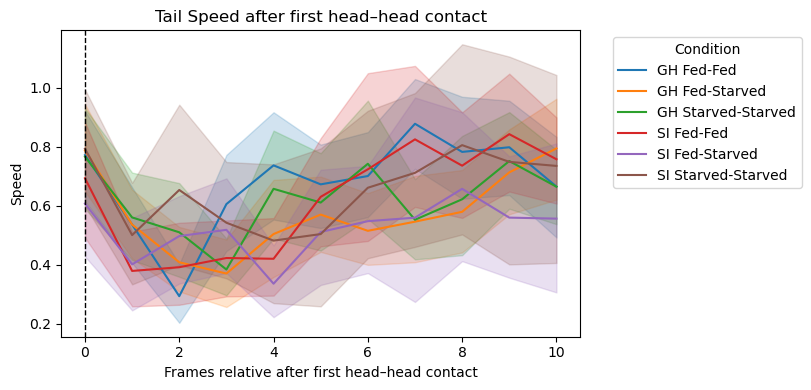

In [9]:
plt.figure(figsize=(6,4))

sns.lineplot(
    data=df,
    x='rel_frame',
    y='speed_tail',
    hue='Condition',
    errorbar=('ci', 95)
)


plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Frames relative after first head–head contact')
plt.ylabel('Speed')
plt.title('Tail Speed after first head–head contact')
plt.tight_layout()

plt.legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# plt.savefig('/speed.png', dpi=300, bbox_inches='tight')
plt.show()

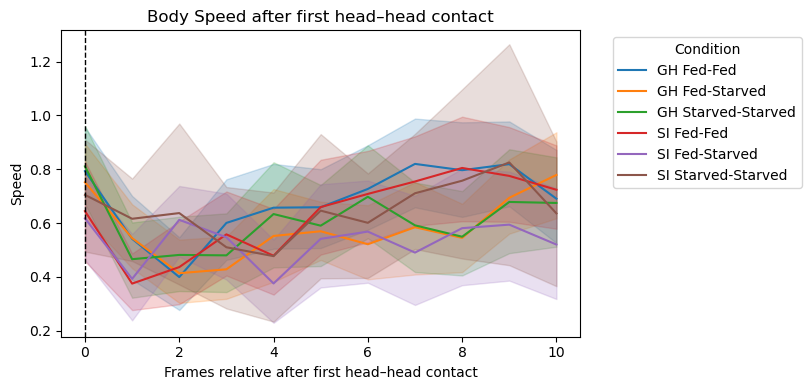

In [11]:
plt.figure(figsize=(6,4))

sns.lineplot(
    data=df,
    x='rel_frame',
    y='speed_body',
    hue='Condition',
    errorbar=('ci', 95)
)


plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Frames relative after first head–head contact')
plt.ylabel('Speed')
plt.title('Body Speed after first head–head contact')
plt.tight_layout()

plt.legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# plt.savefig('/speed.png', dpi=300, bbox_inches='tight')
plt.show()

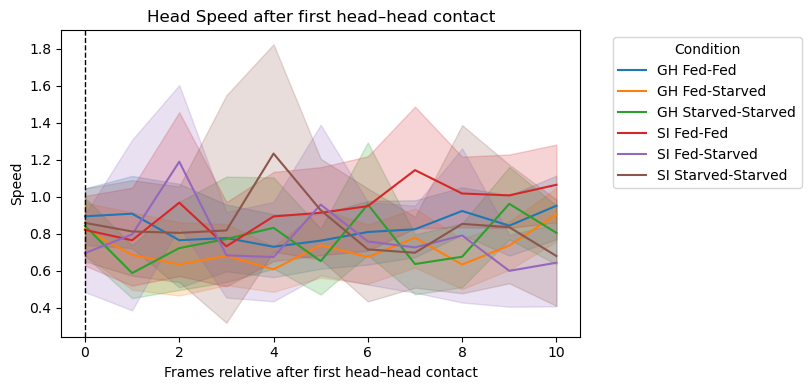

In [10]:
plt.figure(figsize=(6,4))

sns.lineplot(
    data=df,
    x='rel_frame',
    y='speed_head',
    hue='Condition',
    errorbar=('ci', 95)
)


plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Frames relative after first head–head contact')
plt.ylabel('Speed')
plt.title('Head Speed after first head–head contact')
plt.tight_layout()

plt.legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# plt.savefig('/speed.png', dpi=300, bbox_inches='tight')
plt.show()

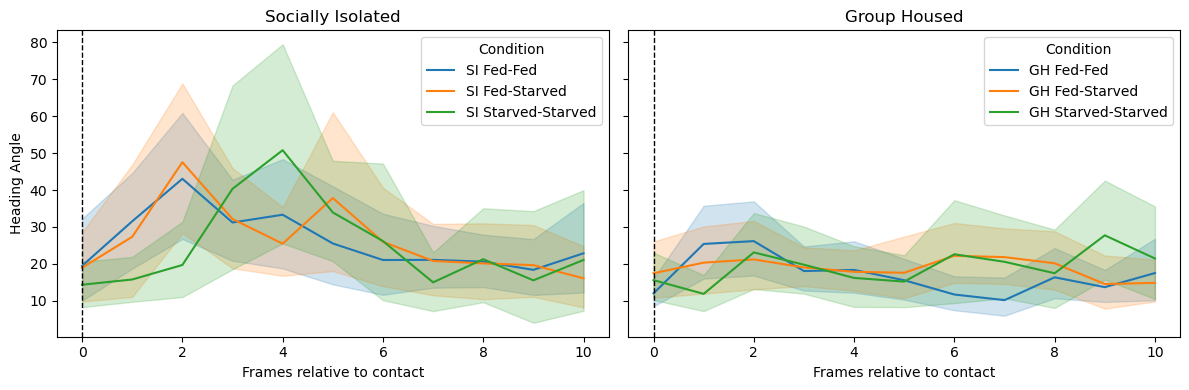

In [15]:
si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='rel_frame',
    y='heading_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Socially Isolated')
axes[0].set_xlabel('Frames relative to contact')
axes[0].set_ylabel('Heading Angle')

# GH
sns.lineplot(
    data=gh,
    x='rel_frame',
    y='heading_angle',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Group Housed')
axes[1].set_xlabel('Frames relative to contact')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


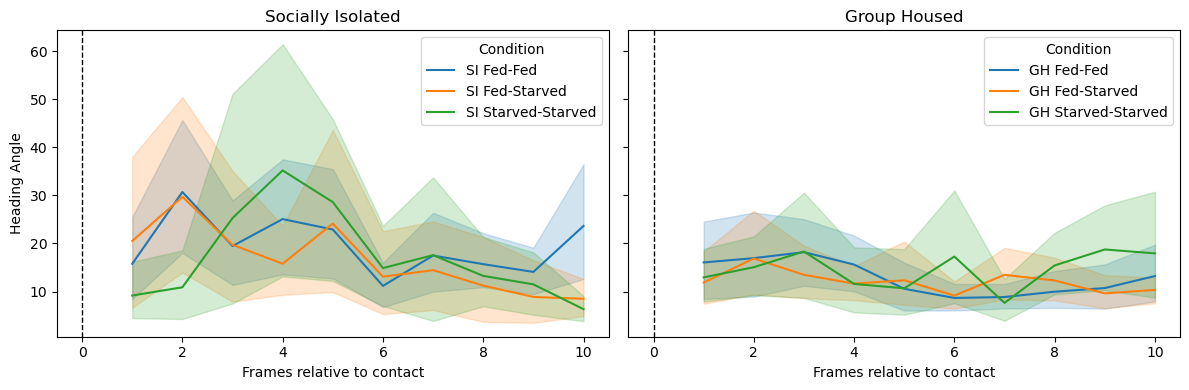

In [16]:
si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Socially Isolated')
axes[0].set_xlabel('Frames relative to contact')
axes[0].set_ylabel('Heading Angle')

# GH
sns.lineplot(
    data=gh,
    x='rel_frame',
    y='heading_angle_change',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Group Housed')
axes[1].set_xlabel('Frames relative to contact')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


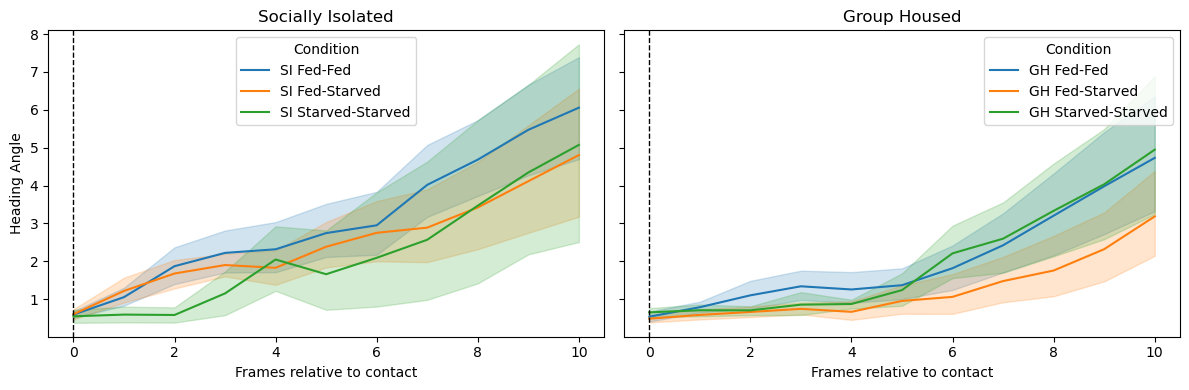

In [17]:
si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# SI
sns.lineplot(
    data=si,
    x='rel_frame',
    y='min_distance',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Socially Isolated')
axes[0].set_xlabel('Frames relative to contact')
axes[0].set_ylabel('Heading Angle')

# GH
sns.lineplot(
    data=gh,
    x='rel_frame',
    y='min_distance',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Group Housed')
axes[1].set_xlabel('Frames relative to contact')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
